In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency
%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
BASE_DIR = "../"
DATA_PATH = os.path.join(BASE_DIR, "data", "cancer_data_eng.csv")
IMG_DIR = os.path.join(BASE_DIR, "img")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

In [3]:

print("\n[0] 加载数据...")
df = pd.read_csv(DATA_PATH, low_memory=False, encoding='latin-1')

# 创建目标变量: VIVO=1 (alive), MORTO=0 (dead)
# 使用 map 而非 == 比较，避免缺失值被误判为 MORTO(0)
df['target'] = df['Status.Vital'].map({'VIVO': 1, 'MORTO': 0})

# 仅保留目标变量非缺失的样本
df_model = df.dropna(subset=['target']).copy()
print(f"    原始样本量: {len(df):,}")
print(f"    有标签样本: {len(df_model):,}")
print(f"      VIVO(存活): {(df_model['target'] == 1).sum():,}  ({(df_model['target'] == 1).mean() * 100:.2f}%)")
print(f"      MORTO(死亡): {(df_model['target'] == 0).sum():,}  ({(df_model['target'] == 0).mean() * 100:.2f}%)")



[0] 加载数据...
    原始样本量: 1,778,176
    有标签样本: 209,758
      VIVO(存活): 85,896  (40.95%)
      MORTO(死亡): 123,862  (59.05%)


# 步骤 1: 特征分类

In [4]:

# 识别数值型和分类型候选
all_cols = df_model.columns.tolist()
exclude_cols = ['Patient.Code', 'target', 'Status.Vital',
                'Date.of.Birth', 'Date.of.Death', 'Date.of.Last.Contact',
                'Date.of.Diagnostic']

# 数值型候选
numeric_candidates = ['Age', 'Code.Profession', 'Code.of.Morphology', 'year']

# 分类型候选 (根据领域知识和低缺失率筛选)
categorical_candidates = [
    'Gender', 'Raca.Color', 'Diagnostic.means', 'Extension',
    'Laterality', 'State.Civil', 'Degree.of.Education',
    'Description.of.Topography', 'Topography.Code',
    'Morphology.Description', 'Description.of.Disease',
    'Illness.Code', 'Child.Illness.Description',
    'Youth.Adult.Illness.Description', 'Type.of.Death',
    'Distant.metastasis', 'Nationality', 'Naturality.State'
]

# 过滤: 确保列存在且在排除列表之外
numeric_features = [c for c in numeric_candidates
                    if c in df_model.columns and c not in exclude_cols]
categorical_features = [c for c in categorical_candidates
                        if c in df_model.columns and c not in exclude_cols]

# Bonferroni 校正: 在所有特征(数值+分类)上统一校正
total_n_features = len(numeric_features) + len(categorical_features)

print(f"\n  数值特征: {numeric_features}")
print(f"  类别特征: {categorical_features}")
print(f"  总特征数(用于Bonferroni校正): {total_n_features}")




  数值特征: ['Age', 'Code.Profession', 'Code.of.Morphology', 'year']
  类别特征: ['Gender', 'Raca.Color', 'Diagnostic.means', 'Extension', 'Laterality', 'State.Civil', 'Degree.of.Education', 'Description.of.Topography', 'Topography.Code', 'Morphology.Description', 'Description.of.Disease', 'Illness.Code', 'Child.Illness.Description', 'Youth.Adult.Illness.Description', 'Type.of.Death', 'Distant.metastasis', 'Nationality', 'Naturality.State']
  总特征数(用于Bonferroni校正): 22


In [5]:

# ============================================================================
# 辅助函数: 判断正态性 (对大样本使用偏度 + D'Agostino-Pearson)
# ============================================================================
def check_normality_practical(data, sample_limit=5000):
    """实用正态性判断: 偏度法 + 大样本近似"""
    data_clean = data.dropna()
    if len(data_clean) < 30:
        return False, "样本不足"

    skewness = data_clean.skew()

    # 如果数据太大，抽样做正式检验
    if len(data_clean) > sample_limit:
        data_test = data_clean.sample(sample_limit, random_state=42)
    else:
        data_test = data_clean

    # 偏度绝对值 < 0.5 视为近似正态
    if abs(skewness) < 0.5:
        return True, f"近似正态 (偏度={skewness:.3f})"
    elif abs(skewness) < 1.0:
        # 边缘情况: 用 D'Agostino-Pearson 检验辅助判断
        try:
            _, p_value = stats.normaltest(data_test)
            if p_value > 0.05:
                return True, f"正态 (p={p_value:.4f})"
            else:
                return False, f"非正态 (偏度={skewness:.3f}, p={p_value:.4f})"
        except Exception:
            return False, f"非正态 (偏度={skewness:.3f})"
    else:
        return False, f"非正态 (偏度={skewness:.3f})"


# 步骤 2: 数值特征 — 单因素分析

In [6]:

numerical_results = []

for col in numeric_features:
    data = df_model[[col, 'target']].dropna()
    if len(data) < 30:
        continue

    group_vivo = data.loc[data['target'] == 1, col]
    group_morto = data.loc[data['target'] == 0, col]

    if len(group_vivo) < 5 or len(group_morto) < 5:
        continue

    is_normal, norm_note = check_normality_practical(data[col])

    # T检验 (正态) 或 Mann-Whitney U (非正态)
    if is_normal:
        # 方差齐性检验 (Levene)
        levene_stat, levene_p = stats.levene(group_vivo, group_morto)
        equal_var = levene_p > 0.05

        t_stat, p_value = stats.ttest_ind(group_vivo, group_morto, equal_var=equal_var)
        test_used = "T-test (独立样本t检验)"

        # Cohen's d 效应量
        n1, n2 = len(group_vivo), len(group_morto)
        s1, s2 = group_vivo.std(), group_morto.std()
        pooled_std = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
        effect_size = abs((group_vivo.mean() - group_morto.mean()) / pooled_std) if pooled_std > 0 else 0
        effect_type = "Cohen's d"
    else:
        u_stat, p_value = mannwhitneyu(group_vivo, group_morto, alternative='two-sided')
        test_used = "Mann-Whitney U"

        # Rank-biserial correlation (效应量)
        n1, n2 = len(group_vivo), len(group_morto)
        effect_size = abs(1 - (2 * u_stat) / (n1 * n2))
        effect_type = "Rank-biserial r"

    # 判断显著性 (Bonferroni 校正)
    mean_v = group_vivo.mean()
    mean_m = group_morto.mean()
    median_v = group_vivo.median()
    median_m = group_morto.median()

    numerical_results.append({
        'Feature': col,
        'N': len(data),
        'Test': test_used,
        'Normality': norm_note,
        'Mean_VIVO': mean_v,
        'Mean_MORTO': mean_m,
        'Median_VIVO': median_v,
        'Median_MORTO': median_m,
        'Statistic': t_stat if is_normal else u_stat,
        'P_Value': p_value,
        'Effect_Size': effect_size,
        'Effect_Type': effect_type,
        'Significant_0.05': 'Yes' if p_value < 0.05 else 'No',
        'Significant_Bonf': 'Yes' if p_value < 0.05 / total_n_features else 'No'
    })

    print(f"\n  ▶ {col}")
    print(f"     检验方法: {test_used}  |  正态性判断: {norm_note}")
    print(f"     VIVO: μ={mean_v:.2f}, M={median_v:.1f}  |  MORTO: μ={mean_m:.2f}, M={median_m:.1f}")
    print(f"     p_value = {p_value:.6e}  |  效应量({effect_type}) = {effect_size:.4f}")

num_df = pd.DataFrame(numerical_results)


  ▶ Age
     检验方法: Mann-Whitney U  |  正态性判断: 非正态 (偏度=-0.683, p=0.0000)
     VIVO: μ=60.39, M=62.0  |  MORTO: μ=66.14, M=68.0
     p_value = 0.000000e+00  |  效应量(Rank-biserial r) = 0.2084

  ▶ Code.Profession
     检验方法: Mann-Whitney U  |  正态性判断: 非正态 (偏度=0.940, p=0.0000)
     VIVO: μ=171.81, M=0.0  |  MORTO: μ=251.06, M=0.0
     p_value = 0.000000e+00  |  效应量(Rank-biserial r) = 0.1477

  ▶ Code.of.Morphology
     检验方法: Mann-Whitney U  |  正态性判断: 非正态 (偏度=2.634)
     VIVO: μ=82658.11, M=80973.0  |  MORTO: μ=82269.73, M=80003.0
     p_value = 0.000000e+00  |  效应量(Rank-biserial r) = 0.4677

  ▶ year
     检验方法: Mann-Whitney U  |  正态性判断: 非正态 (偏度=-1.004)
     VIVO: μ=2013.80, M=2015.0  |  MORTO: μ=2011.15, M=2011.0
     p_value = 0.000000e+00  |  效应量(Rank-biserial r) = 0.4387


# 步骤 3: 分类特征 — 卡方检验

In [8]:

categorical_results = []

for col in categorical_features:
    data = df_model[[col, 'target']].dropna()
    if len(data) < 30:
        continue

    # 统计每个类别中的样本数
    value_counts = data[col].value_counts()
    # 过滤掉太稀疏的类别 (频数 < 5 可能导致卡方检验不稳定)
    valid_categories = value_counts[value_counts >= 5].index
    data_filtered = data[data[col].isin(valid_categories)]

    if len(data_filtered) < 30:
        continue

    # 构建列联表
    contingency = pd.crosstab(data_filtered[col], data_filtered['target'])

    # 如果列联表太小或太大，跳过
    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        continue

    # 卡方检验
    try:
        chi2_stat, p_value, dof, expected = chi2_contingency(contingency)
    except Exception:
        continue

    # Cramér's V 效应量
    n_total = contingency.values.sum()
    phi2 = chi2_stat / n_total
    k = min(contingency.shape) - 1
    cramer_v = np.sqrt(phi2 / k) if k > 0 else 0

    # 判断显著性 (Bonferroni 校正
    categorical_results.append({
        'Feature': col,
        'N': len(data_filtered),
        'Categories': contingency.shape[0],
        'Chi2': chi2_stat,
        'P_Value': p_value,
        'Cramér_V': cramer_v,
        'Significant_0.05': 'Yes' if p_value < 0.05 else 'No',
        'Significant_Bonf': 'Yes' if p_value < 0.05 / total_n_features else 'No'
    })

    print(f"\n  ▶ {col}")
    print(f"     有效类别数: {contingency.shape[0]}")
    print(f"     χ² = {chi2_stat:.2f}, p = {p_value:.6e}")
    print(f"     Cramér's V = {cramer_v:.4f}")

cat_df = pd.DataFrame(categorical_results)


  ▶ Gender
     有效类别数: 3
     χ² = 1768.83, p = 0.000000e+00
     Cramér's V = 0.0918

  ▶ Raca.Color
     有效类别数: 5
     χ² = 4816.48, p = 0.000000e+00
     Cramér's V = 0.1646

  ▶ Diagnostic.means
     有效类别数: 7
     χ² = 72603.65, p = 0.000000e+00
     Cramér's V = 0.5894

  ▶ Extension
     有效类别数: 4
     χ² = 26974.88, p = 0.000000e+00
     Cramér's V = 0.5711

  ▶ Laterality
     有效类别数: 4
     χ² = 363.40, p = 1.869493e-78
     Cramér's V = 0.0587

  ▶ State.Civil
     有效类别数: 5
     χ² = 1821.52, p = 0.000000e+00
     Cramér's V = 0.1090

  ▶ Degree.of.Education
     有效类别数: 6
     χ² = 3206.90, p = 0.000000e+00
     Cramér's V = 0.1509

  ▶ Description.of.Topography
     有效类别数: 323
     χ² = 78250.35, p = 0.000000e+00
     Cramér's V = 0.6110

  ▶ Topography.Code
     有效类别数: 323
     χ² = 78250.35, p = 0.000000e+00
     Cramér's V = 0.6110

  ▶ Morphology.Description
     有效类别数: 362
     χ² = 101412.44, p = 0.000000e+00
     Cramér's V = 0.6959

  ▶ Description.of.Disease
     有效类

In [9]:

# 合并数值和分类结果
all_results = []

for _, row in num_df.iterrows():
    all_results.append({
        'Feature': row['Feature'],
        'Type': '数值型',
        'Test': row['Test'],
        'P_Value': row['P_Value'],
        'Effect_Size': row['Effect_Size'],
        'Effect_Type': row['Effect_Type'],
        'Significant_0.05': row['Significant_0.05'],
        'Significant_Bonf': row['Significant_Bonf']
    })

for _, row in cat_df.iterrows():
    all_results.append({
        'Feature': row['Feature'],
        'Type': '分类型',
        'Test': '卡方检验',
        'P_Value': row['P_Value'],
        'Effect_Size': row['Cramér_V'],
        'Effect_Type': "Cramér's V",
        'Significant_0.05': row['Significant_0.05'],
        'Significant_Bonf': row['Significant_Bonf']
    })

summary_df = pd.DataFrame(all_results).sort_values('P_Value')

print(f"\n  ▶ 共分析 {len(all_results)} 个特征:")
print(f"     数值型: {len(num_df)}  |  分类型: {len(cat_df)}")
print(f"\n  ▶ 在 α=0.05 水平显著: {summary_df['Significant_0.05'].value_counts().get('Yes', 0)} 个")
print(f"  ▶ Bonferroni 校正后显著: {summary_df['Significant_Bonf'].value_counts().get('Yes', 0)} 个")

print(f"\n  ▶ 按 p 值排序的显著变量列表:")
sig_df = summary_df[summary_df['Significant_0.05'] == 'Yes']
print(f"     {'特征':<30} {'类型':<8} {'检验方法':<22} {'p值':<14} {'效应量':<10}")
print(f"     {'-'*30} {'-'*8} {'-'*22} {'-'*14} {'-'*10}")
for _, row in sig_df.iterrows():
    print(f"     {row['Feature']:<30} {row['Type']:<8} {row['Test']:<22} {row['P_Value']:<14.6e} {row['Effect_Size']:<10.4f}")



  ▶ 共分析 22 个特征:
     数值型: 4  |  分类型: 18

  ▶ 在 α=0.05 水平显著: 22 个
  ▶ Bonferroni 校正后显著: 22 个

  ▶ 按 p 值排序的显著变量列表:
     特征                             类型       检验方法                   p值             效应量       
     ------------------------------ -------- ---------------------- -------------- ----------
     Age                            数值型      Mann-Whitney U         0.000000e+00   0.2084    
     Distant.metastasis             分类型      卡方检验                   0.000000e+00   0.4665    
     Youth.Adult.Illness.Description 分类型      卡方检验                   0.000000e+00   0.6801    
     Illness.Code                   分类型      卡方检验                   0.000000e+00   0.6385    
     Description.of.Disease         分类型      卡方检验                   0.000000e+00   0.6225    
     Morphology.Description         分类型      卡方检验                   0.000000e+00   0.6959    
     Topography.Code                分类型      卡方检验                   0.000000e+00   0.6110    
     Description.of.Topography      分类型

  [图] 05_pvalue_comparison.png → p值对比图已保存


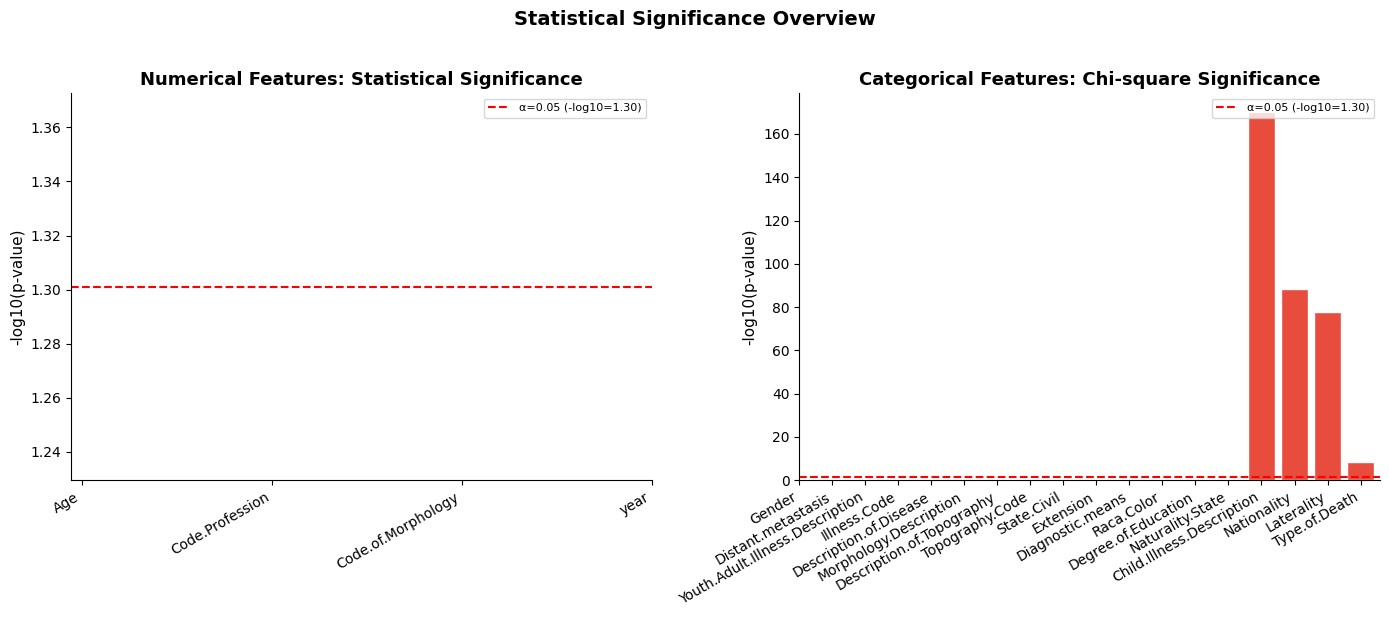

In [10]:

# --- 图 5a: P-value 对比柱状图 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 数值特征 p-value
if len(num_df) > 0:
    num_plot = num_df.sort_values('P_Value')
    colors_num = ['#e74c3c' if p < 0.05 else '#3498db' for p in num_plot['P_Value']]
    ax = axes[0]
    bars = ax.bar(range(len(num_plot)), -np.log10(num_plot['P_Value'].values),
                  color=colors_num, edgecolor='white')
    ax.axhline(y=-np.log10(0.05), color='red', linestyle='--', linewidth=1.5,
               label=f'α=0.05 (-log10={-np.log10(0.05):.2f})')
    ax.set_xticks(range(len(num_plot)))
    ax.set_xticklabels(num_plot['Feature'].values, rotation=30, ha='right')
    ax.set_ylabel('-log10(p-value)', fontsize=11)
    ax.set_title('Numerical Features: Statistical Significance', fontsize=13, fontweight='bold')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 分类特征 p-value
if len(cat_df) > 0:
    cat_plot = cat_df.sort_values('P_Value')
    colors_cat = ['#e74c3c' if p < 0.05 else '#3498db' for p in cat_plot['P_Value']]
    ax = axes[1]
    bars = ax.bar(range(len(cat_plot)), -np.log10(cat_plot['P_Value'].values),
                  color=colors_cat, edgecolor='white')
    ax.axhline(y=-np.log10(0.05), color='red', linestyle='--', linewidth=1.5,
               label=f'α=0.05 (-log10={-np.log10(0.05):.2f})')
    ax.set_xticks(range(len(cat_plot)))
    ax.set_xticklabels(cat_plot['Feature'].values, rotation=30, ha='right')
    ax.set_ylabel('-log10(p-value)', fontsize=11)
    ax.set_title('Categorical Features: Chi-square Significance', fontsize=13, fontweight='bold')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Statistical Significance Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "05_pvalue_comparison.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 05_pvalue_comparison.png → p值对比图已保存")


  [图] 05b_effect_size_comparison.png → 效应量对比图已保存


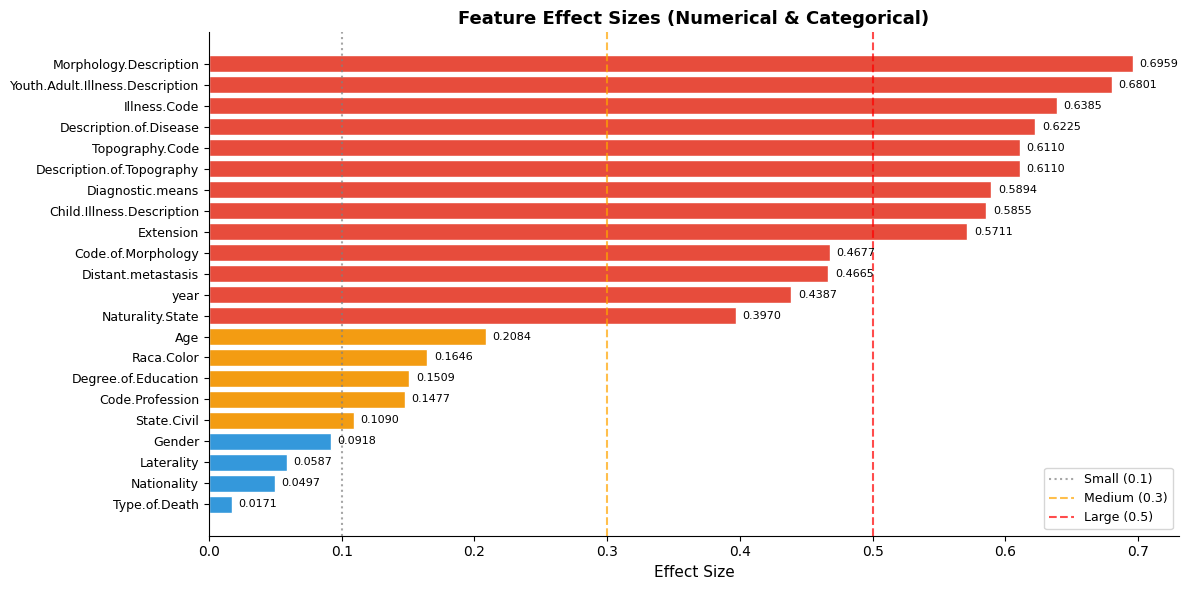

In [11]:

# --- 图 5b: 效应量对比图 ---
if len(all_results) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    plot_df = summary_df.sort_values('Effect_Size', ascending=True)

    colors_effect = ['#e74c3c' if row['Effect_Size'] > 0.3
                     else ('#f39c12' if row['Effect_Size'] > 0.1 else '#3498db')
                     for _, row in plot_df.iterrows()]

    bars = ax.barh(range(len(plot_df)), plot_df['Effect_Size'].values,
                   color=colors_effect, edgecolor='white')
    ax.set_yticks(range(len(plot_df)))
    ax.set_yticklabels(plot_df['Feature'].values, fontsize=9)
    ax.set_xlabel('Effect Size', fontsize=11)
    ax.set_title('Feature Effect Sizes (Numerical & Categorical)', fontsize=13, fontweight='bold')

    # 效应量参考线
    ax.axvline(x=0.1, color='gray', linestyle=':', alpha=0.7, label='Small (0.1)')
    ax.axvline(x=0.3, color='orange', linestyle='--', alpha=0.7, label='Medium (0.3)')
    ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Large (0.5)')
    ax.legend(fontsize=9)

    for bar, val in zip(bars, plot_df['Effect_Size'].values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(IMG_DIR, "05b_effect_size_comparison.png"), dpi=150, bbox_inches='tight')
    # plt.close()
    print("  [图] 05b_effect_size_comparison.png → 效应量对比图已保存")


  [图] 05c_pvalue_vs_effectsize.png → p值-效应量散点图已保存


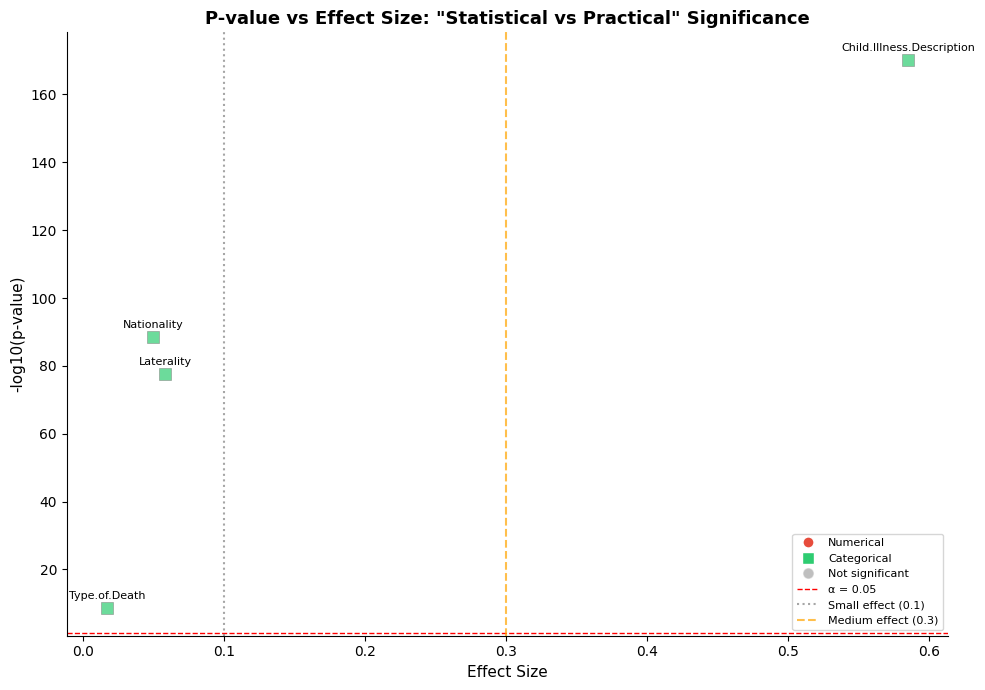

In [12]:

# --- 图 5c: p值 vs 效应量散点图 ---
if len(all_results) >= 3:
    fig, ax = plt.subplots(figsize=(10, 7))

    for _, row in summary_df.iterrows():
        color = '#e74c3c' if row['Type'] == '数值型' else '#2ecc71'
        size = 80 if row['Significant_0.05'] == 'Yes' else 40
        marker = 'o' if row['Type'] == '数值型' else 's'
        ax.scatter(row['Effect_Size'], -np.log10(row['P_Value']),
                   c=color, s=size, marker=marker, alpha=0.7, edgecolors='gray',
                   linewidths=0.5)

        # 标注特征名
        ax.annotate(row['Feature'],
                    (row['Effect_Size'], -np.log10(row['P_Value'])),
                    fontsize=8, ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points')

    ax.axhline(y=-np.log10(0.05), color='red', linestyle='--', linewidth=1,
               label='α = 0.05')
    ax.axvline(x=0.1, color='gray', linestyle=':', alpha=0.7, label='Small effect (0.1)')
    ax.axvline(x=0.3, color='orange', linestyle='--', alpha=0.7, label='Medium effect (0.3)')

    # 图例
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c',
               markersize=8, label='Numerical'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='#2ecc71',
               markersize=8, label='Categorical'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
               markersize=8, alpha=0.5, label='Not significant')
    ]
    ax.legend(handles=legend_elements + ax.get_legend_handles_labels()[0][-3:],
              fontsize=8, loc='lower right')

    ax.set_xlabel('Effect Size', fontsize=11)
    ax.set_ylabel('-log10(p-value)', fontsize=11)
    ax.set_title('P-value vs Effect Size: "Statistical vs Practical" Significance',
                 fontsize=13, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(IMG_DIR, "05c_pvalue_vs_effectsize.png"), dpi=150, bbox_inches='tight')
    # plt.close()
    print("  [图] 05c_pvalue_vs_effectsize.png → p值-效应量散点图已保存")
